# AOMIC-ID1000 - Brain Preprocessing and Visualisation

Two brain modalities feed the highest tiers, as separate ontology domains:
**morphometry** (FreeSurfer volumes and cortical thickness) and **connectome**
(Schaefer-100 / Yeo-7 functional connectivity from movie-watching fMRI). This
notebook visualises both and their relationship to intelligence.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent
IND = "#6366f1"; GRN = "#10b981"; ORG = "#f59e0b"; RED = "#ef4444"; BLU = "#38bdf8"

from nilearn import plotting, datasets
part = pd.read_csv(ROOT / "dataset" / "participants.tsv", sep="\t", na_values=["n/a",""])
target = pd.to_numeric(part.set_index("participant_id")["IST_intelligence_total"], errors="coerce")
morph = pd.read_csv(ROOT / "brain" / "freesurfer" / "morphometry_features.csv", index_col=0)
conn = pd.read_csv(ROOT / "brain" / "connectome" / "connectome_features.csv", index_col=0)
fc_dir = ROOT / "brain" / "connectome" / "network_fc"
print("morphometry", morph.shape, "| connectome", conn.shape)

morphometry (120, 35) | connectome (23, 28)


## 1. Subcortical volumes: distribution and hemispheric symmetry

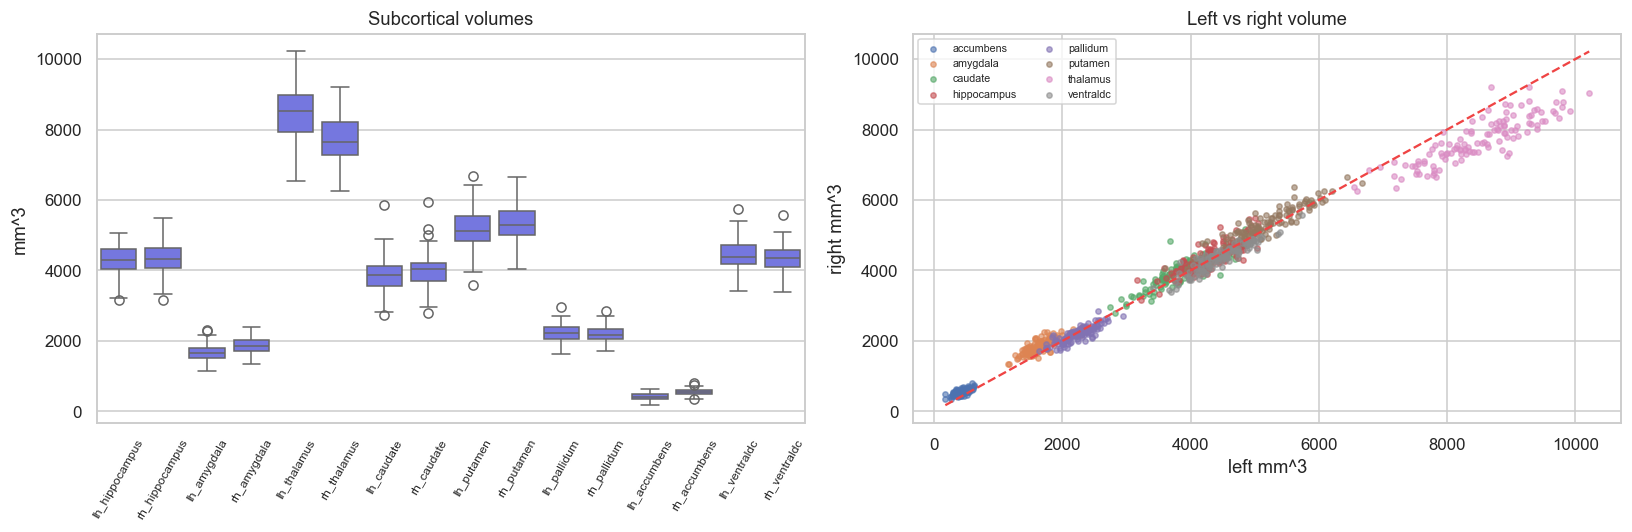

In [2]:
sub = [c for c in morph.columns if c.startswith("fs_vol_")]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
m = morph[sub].melt(var_name="s", value_name="v"); m["s"]=m["s"].str.replace("fs_vol_","",regex=False)
sns.boxplot(data=m, x="s", y="v", ax=ax[0], color=IND); ax[0].tick_params(axis="x", rotation=60, labelsize=8)
ax[0].set(title="Subcortical volumes", ylabel="mm^3", xlabel="")
structs = sorted(set(c.replace("fs_vol_lh_","").replace("fs_vol_rh_","") for c in sub))
for s in structs:
    l, r = f"fs_vol_lh_{s}", f"fs_vol_rh_{s}"
    if l in morph and r in morph:
        ax[1].scatter(morph[l], morph[r], s=12, alpha=0.6, label=s)
lims=[morph[sub].min().min(), morph[sub].max().max()]
ax[1].plot(lims, lims, color=RED, ls="--"); ax[1].set(title="Left vs right volume", xlabel="left mm^3", ylabel="right mm^3")
ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 2. Head-size scaling and lobe thickness map

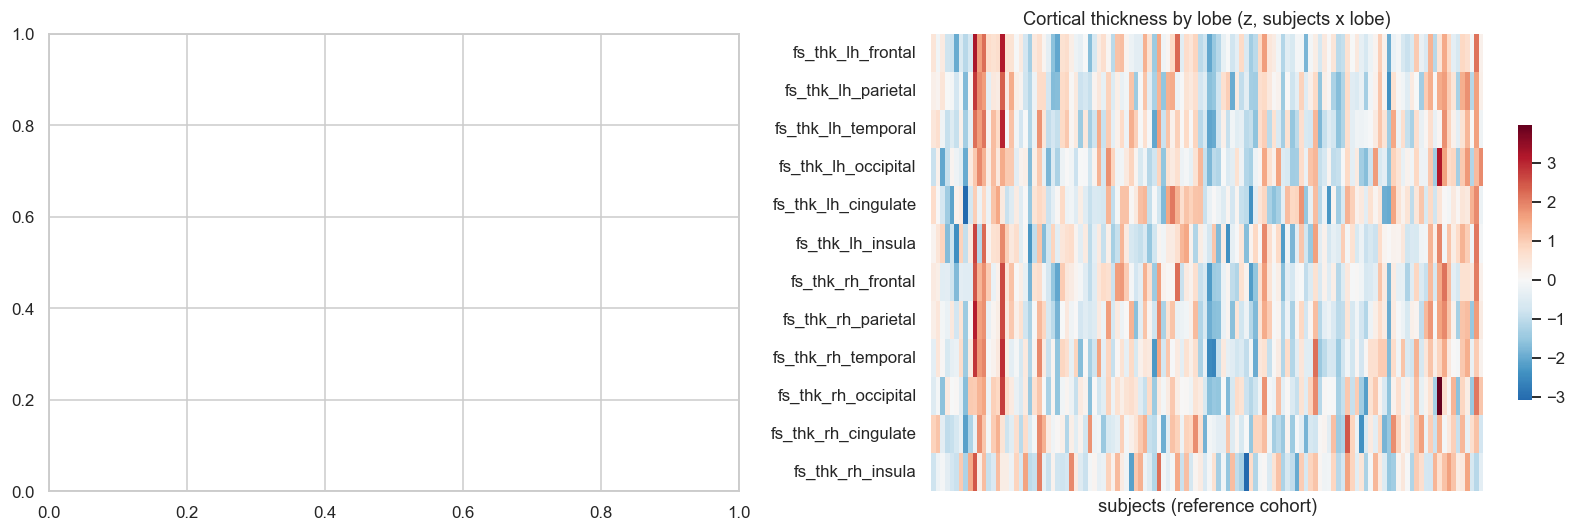

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
if "fs_etiv" in morph:
    for c,col in zip(["fs_total_gray_vol","fs_cerebral_wm_vol","fs_subcort_gray_vol"],[GRN,ORG,BLU]):
        if c in morph: ax[0].scatter(morph["fs_etiv"], morph[c], s=12, alpha=0.6, label=c, color=col)
    ax[0].set(title="Tissue volumes scale with intracranial volume", xlabel="eTIV mm^3", ylabel="volume mm^3"); ax[0].legend(fontsize=8)
thk = [c for c in morph.columns if c.startswith("fs_thk_")]
z = (morph[thk]-morph[thk].mean())/morph[thk].std()
sns.heatmap(z.T, cmap="RdBu_r", center=0, ax=ax[1], cbar_kws={"shrink":.6}, xticklabels=False)
ax[1].set(title="Cortical thickness by lobe (z, subjects x lobe)", xlabel="subjects (reference cohort)")
plt.tight_layout(); plt.show()

## 3. Morphometry correlation structure and links to intelligence

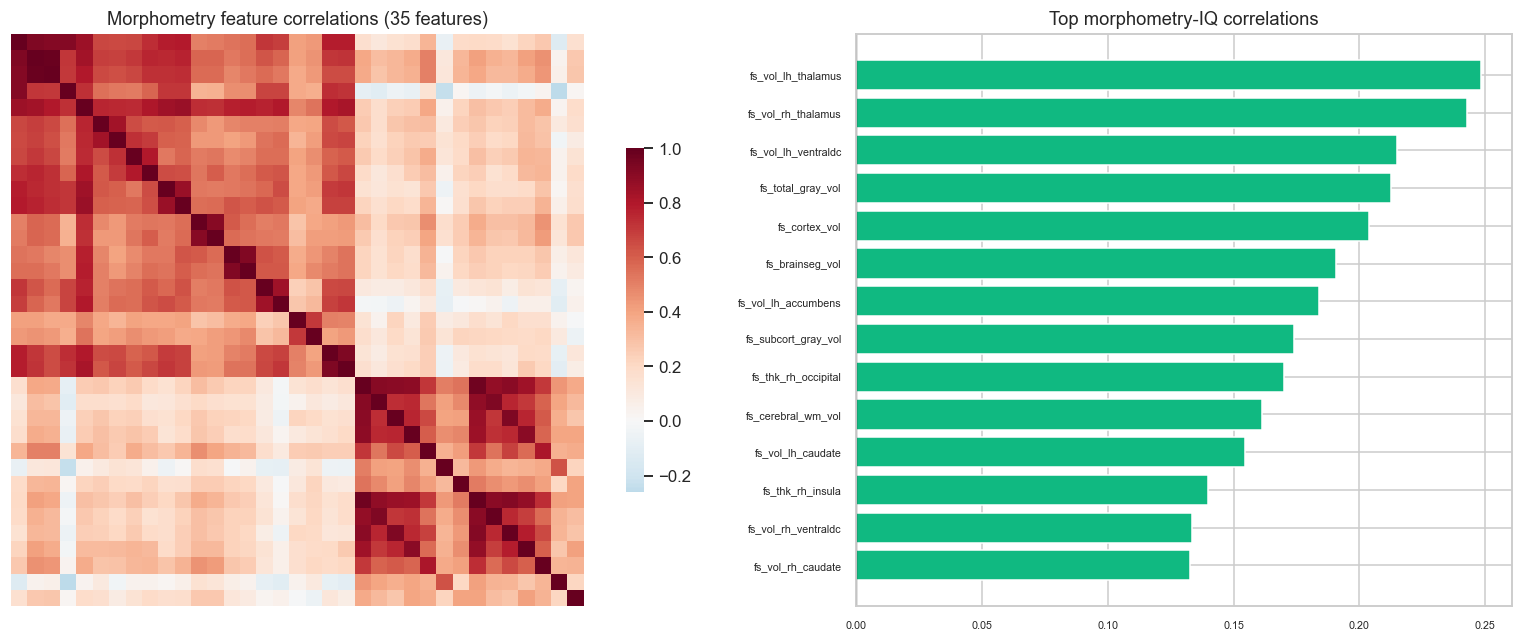

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[1.3,1]})
sns.heatmap(morph.corr(), cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.6}, ax=ax[0], xticklabels=False, yticklabels=False)
ax[0].set_title("Morphometry feature correlations (35 features)")
tgt = target.reindex(morph.index)
rows=[]
for c in morph.columns:
    mm = morph[c].notna() & tgt.notna()
    if mm.sum()>30: rows.append((c, float(np.corrcoef(morph[c][mm], tgt[mm])[0,1])))
rho = pd.DataFrame(rows, columns=["f","r"]).sort_values("r")
rho2 = rho.reindex(rho["r"].abs().sort_values(ascending=False).index).head(14).sort_values("r")
ax[1].barh(rho2["f"], rho2["r"], color=[RED if v<0 else GRN for v in rho2["r"]])
ax[1].axvline(0,color="#333"); ax[1].set_title("Top morphometry-IQ correlations"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

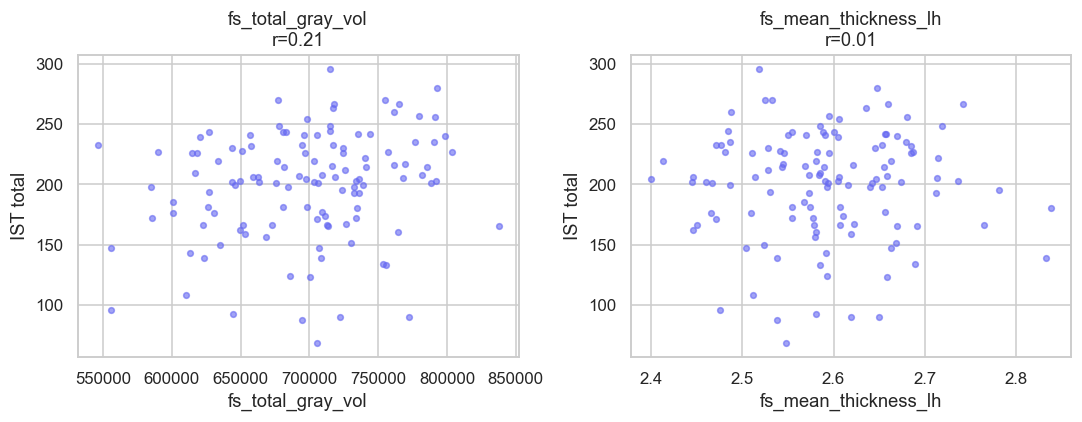

In [5]:
glob = [c for c in ["fs_etiv","fs_total_gray_vol","fs_mean_thickness_lh"] if c in morph]
fig, ax = plt.subplots(1, len(glob), figsize=(5*len(glob), 4))
for a, c in zip(np.atleast_1d(ax), glob):
    mm = morph[c].notna() & tgt.notna()
    a.scatter(morph[c][mm], tgt[mm], s=14, alpha=0.6, color=IND)
    r = np.corrcoef(morph[c][mm], tgt[mm])[0,1]
    a.set(title=f"{c}\nr={r:.2f}", xlabel=c, ylabel="IST total")
plt.tight_layout(); plt.show()

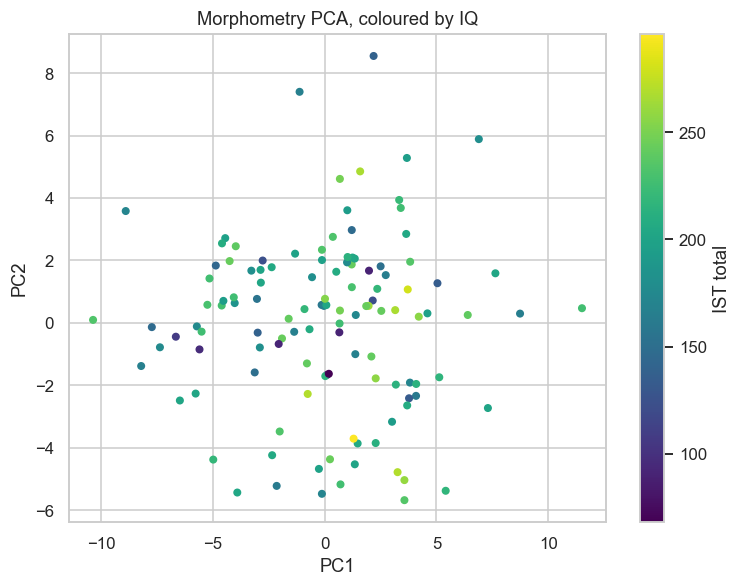

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Mp = morph.dropna()
if len(Mp) > 10:
    Z2 = PCA(2).fit_transform(StandardScaler().fit_transform(Mp))
    fig, axp = plt.subplots(figsize=(7,5.5))
    sc = axp.scatter(Z2[:,0], Z2[:,1], c=target.reindex(Mp.index), cmap="viridis", s=18)
    plt.colorbar(sc, label="IST total"); axp.set(title="Morphometry PCA, coloured by IQ", xlabel="PC1", ylabel="PC2")
    plt.tight_layout(); plt.show()

## 4. Functional connectome: network matrices

<Figure size 715x605 with 0 Axes>

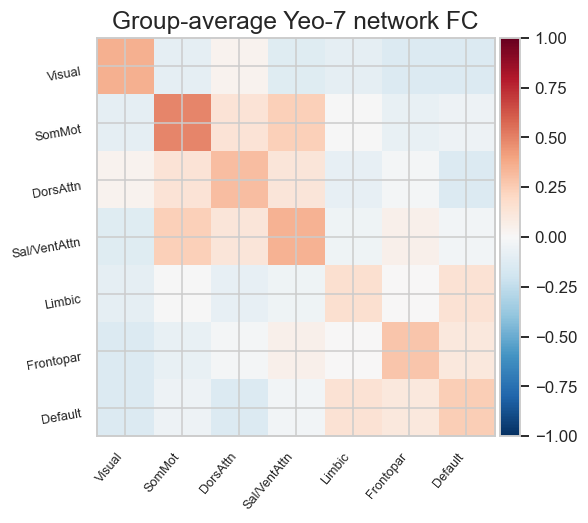

In [7]:
YEO7 = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
LBL = ["Visual","SomMot","DorsAttn","Sal/VentAttn","Limbic","Frontopar","Default"]
mats = {p.stem: np.load(p) for p in sorted(fc_dir.glob("*.npy"))}
group = np.nanmean(np.stack(list(mats.values())), axis=0)
fig = plt.figure(figsize=(6.5,5.5))
plotting.plot_matrix(group, labels=LBL, colorbar=True, vmin=-1, vmax=1, title="Group-average Yeo-7 network FC")
plt.show()

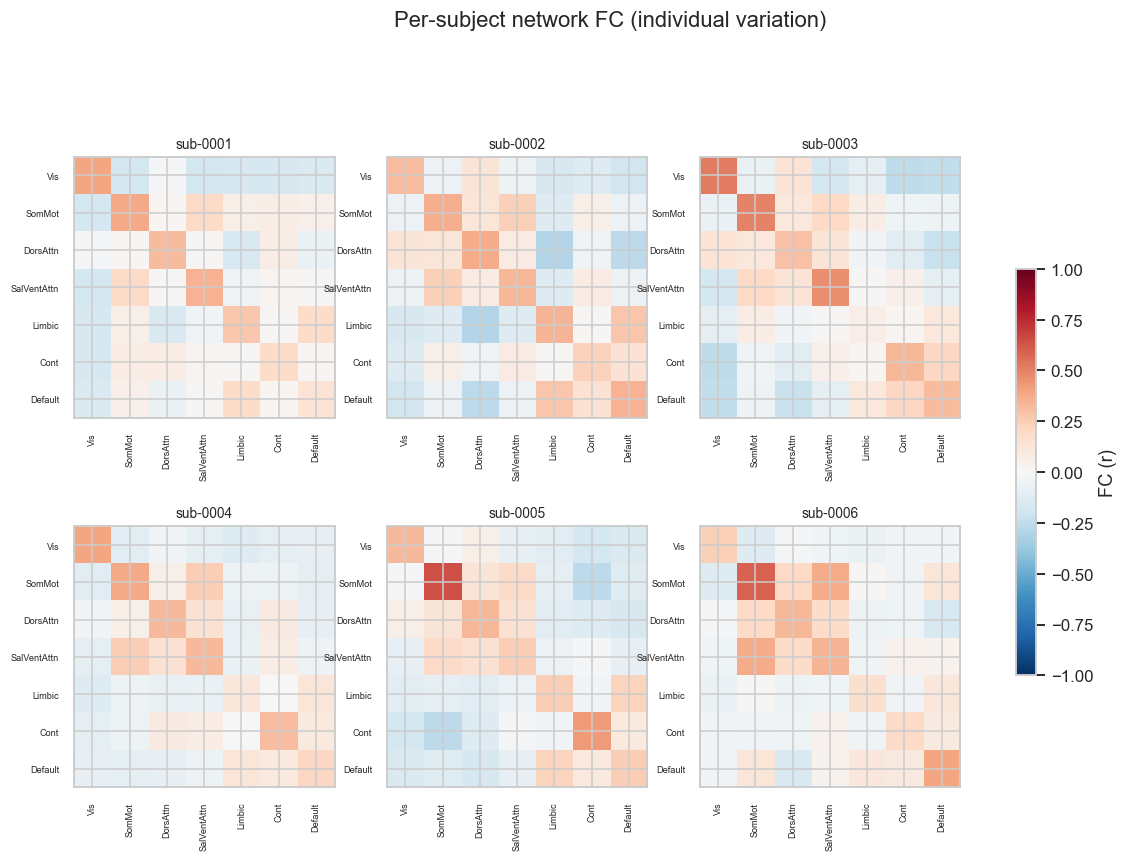

In [8]:
ids = list(mats)[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, pid in zip(axes.flat, ids):
    im = ax.imshow(mats[pid], vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(pid, fontsize=9); ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(YEO7, rotation=90, fontsize=6); ax.set_yticklabels(YEO7, fontsize=6)
fig.colorbar(im, ax=axes, shrink=0.6, label="FC (r)")
plt.suptitle("Per-subject network FC (individual variation)", y=1.02); plt.show()

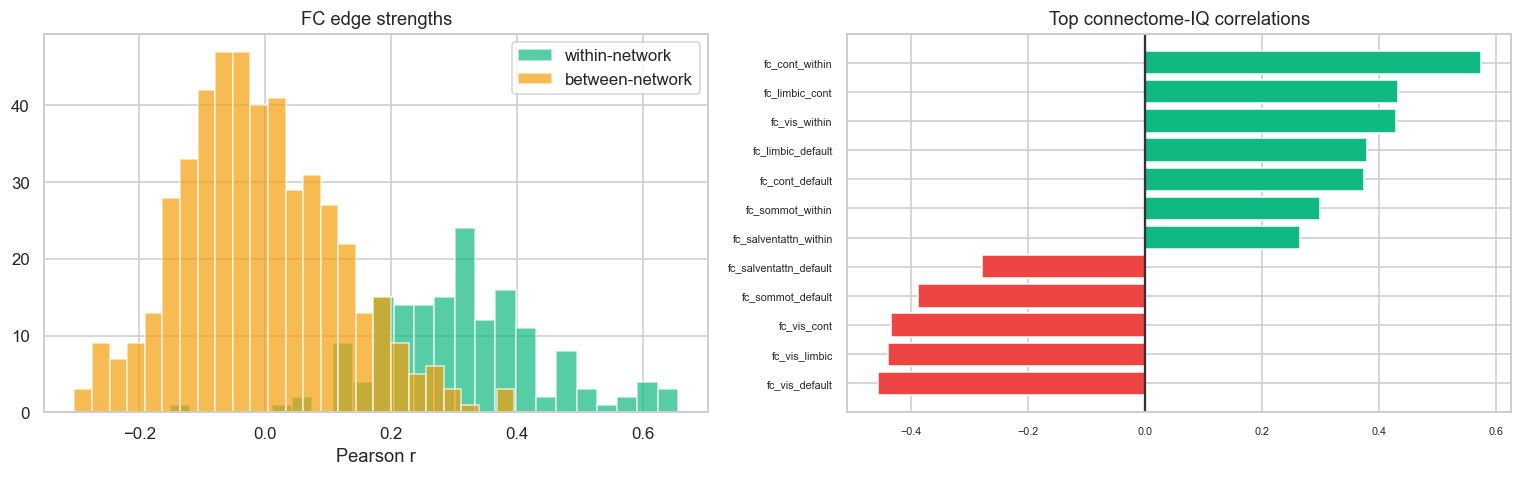

In [9]:
within = [c for c in conn.columns if c.endswith("_within")]
between = [c for c in conn.columns if c not in within]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(conn[within].values.flatten(), bins=25, alpha=0.7, color=GRN, label="within-network")
ax[0].hist(conn[between].values.flatten(), bins=25, alpha=0.7, color=ORG, label="between-network")
ax[0].set(title="FC edge strengths", xlabel="Pearson r"); ax[0].legend()
tgtc = target.reindex(conn.index)
rows=[]
for c in conn.columns:
    mm = conn[c].notna() & tgtc.notna()
    if mm.sum()>15: rows.append((c, float(np.corrcoef(conn[c][mm], tgtc[mm])[0,1])))
rc = pd.DataFrame(rows, columns=["f","r"])
rc = rc.reindex(rc["r"].abs().sort_values(ascending=False).index).head(12).sort_values("r")
ax[1].barh(rc["f"], rc["r"], color=[RED if v<0 else GRN for v in rc["r"]])
ax[1].axvline(0,color="#333"); ax[1].set_title("Top connectome-IQ correlations"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

## 5. Parcel-level connectome and glass brain (one subject)

[get_dataset_dir] Dataset found in /Users/stijnvanseveren/nilearn_data/schaefer_2018

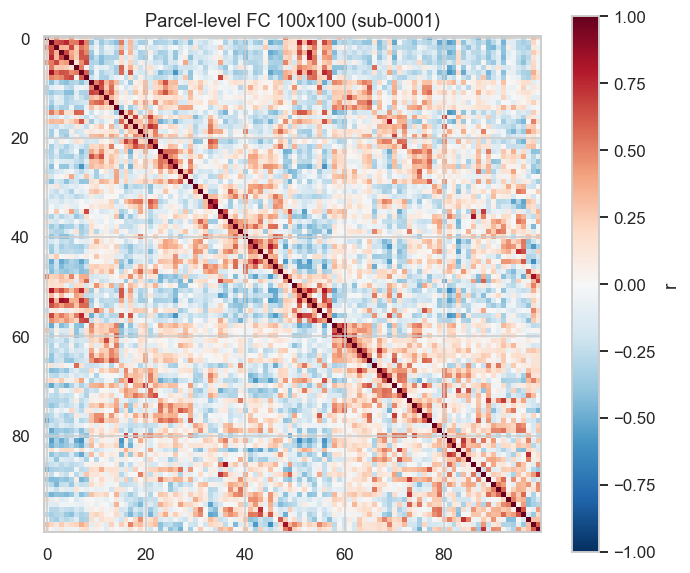

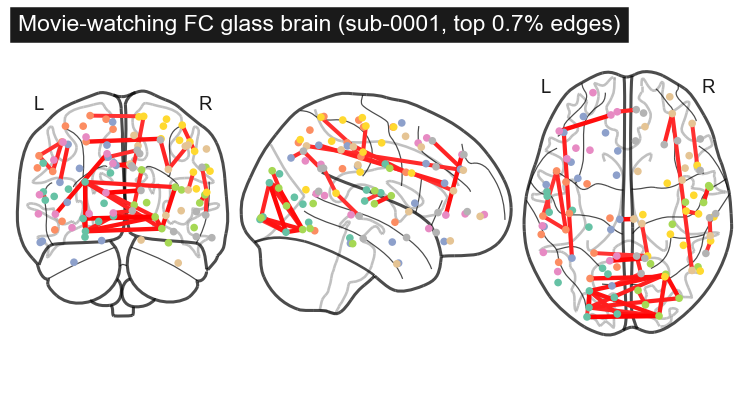

In [10]:
repo = next(p for p in [ROOT,*ROOT.parents] if (p/"src"/"full_stack").is_dir())
sys.path.insert(0, str(repo))
from validation.common import connectome as C
sub = list(mats)[0]
atlas = C.load_atlas(100,7,2); coords = plotting.find_parcellation_cut_coords(atlas.maps)
paths = C.download_func(sub, "ds003097", ROOT/"brain"/"_cache"/"connectome")
ts = C.parcel_timeseries(paths, atlas); pfc = np.corrcoef(ts.T)
fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(pfc, vmin=-1, vmax=1, cmap="RdBu_r"); ax.set_title(f"Parcel-level FC 100x100 ({sub})")
plt.colorbar(im, label="r"); plt.tight_layout(); plt.show()
plotting.plot_connectome(pfc, coords, edge_threshold="99.3%", node_size=16,
                         title=f"Movie-watching FC glass brain ({sub}, top 0.7% edges)")
plt.show()
for k in ("bold","mask"):
    p=paths.get(k)
    if p and Path(p).exists(): Path(p).unlink()

Naturalistic-viewing connectivity varies clearly between individuals; the engine receives the compact 28-value network summary, while these parcel-level views are for inspection. Morphometry and connectome enter the ontology as distinct domains.